# **Introduction**
As electric vehicles (EVs) become more popular, understanding charging behavior is essential for infrastructure planning, user behavior modeling, and cost optimization. The growing network of charging stations, variety of vehicle models, and environmental factors all contribute to complex usage patterns. This project focuses on analyzing a simulated dataset of EV charging sessions to uncover patterns and predict both charging cost and charging demand (measured by energy consumed). 

### **The primary objectives of this study are:**



*   To preprocess and explore the dataset to understand the key variables.
*   To segment the dataset using unsupervised learning (clustering).
*   To predict charging cost and energy demand using supervised machine learning algorithms.

### Data Cleaning and Transformation
First, import libraries and load the CSV file. Then check data types and convert date/time or numerical columns as needed.

This section ensures that all data types are correctly transformed and missing data is managed.

In [10]:
import pandas as pd
import numpy as np
from datetime import datetime

# Load the dataset
df = pd.read_csv('ev_charging_patterns.csv')

# Preview the dataset
print(df.head())

# Convert date columns to datetime (Replace the invalid ones with NaT)
df['Charging Start Time'] = pd.to_datetime(df['Charging Start Time'], errors='coerce')
df['Charging End Time'] = pd.to_datetime(df['Charging End Time'], errors='coerce')

# Convert numeric columns: ensure that Battery Capacity, Energy Consumed, Charging Duration, Charging Rate, Charging Cost, Temperature, Vehicle Age, etc. are numeric.
numeric_cols = ['Battery Capacity (kWh)', 'Energy Consumed (kWh)', 'Charging Duration (hours)',
                'Charging Rate (kW)', 'Charging Cost (USD)', 'Temperature (°C)', 'Vehicle Age (years)']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Finally, handle missing values (drop or impute)
df.dropna(inplace=True)

  User ID Vehicle Model  Battery Capacity (kWh) Charging Station ID  \
0  User_1        BMW i3              108.463007         Station_391   
1  User_2  Hyundai Kona              100.000000         Station_428   
2  User_3    Chevy Bolt               75.000000         Station_181   
3  User_4  Hyundai Kona               50.000000         Station_327   
4  User_5  Hyundai Kona               50.000000         Station_108   

  Charging Station Location  Charging Start Time    Charging End Time  \
0                   Houston  2024-01-01 00:00:00  2024-01-01 00:39:00   
1             San Francisco  2024-01-01 01:00:00  2024-01-01 03:01:00   
2             San Francisco  2024-01-01 02:00:00  2024-01-01 04:48:00   
3                   Houston  2024-01-01 03:00:00  2024-01-01 06:42:00   
4               Los Angeles  2024-01-01 04:00:00  2024-01-01 05:46:00   

   Energy Consumed (kWh)  Charging Duration (hours)  Charging Rate (kW)  \
0              60.712346                   0.591363        

### Data Visualization
After cleaning the data, it’s useful to visualize key distributions and relationships to better understand the underlying patterns.

### Correlation Matrix


Using plt.matshow, the correlation matrix visualizes the linear relationships among numeric variables. This can be useful when deciding which features might be most informative for predictive models. Each cell represents the correlation between two features, ranging from:

*  +1 (yellow): perfect positive correlation
*  0 (dark purple): no correlation
*  -1: perfect negative correlation
Key observations:
*  Diagonal = 1: As expected, all variables are perfectly correlated with themselves.
*  Most off-diagonal values are close to 0, indicating weak relationships between most variables.

There is slightly positive correlation between:
*  Charging Duration and Energy Consumed
*  Charging Cost and Energy Consumed

No strong multicollinearity was found which reduces redundancy.

### Scatter Plot – Charging Duration vs. Energy Consumed


The scatter plot between "Charging Duration (hours)" and "Energy Consumed (kWh)" can reveal potential relationships or trends. For example, longer charging sessions may correspond with higher energy consumption.


Key observations:
*  There is a general upward trend, suggesting a weak positive correlation: longer charging sessions tend to result in more energy consumed.
*  However, the data is widely spread, indicating that charging time alone doesn’t fully explain energy use — other factors (like charger type or battery size) also matter.
*  A few outliers exist: sessions with long duration but low energy, or vice versa. These might indicate inefficient charging or special cases.

<table>
    <tr>
        <th>Long duration but low energy consumed</th>
        <th>Short duration but high energy consumed</th>
    </tr>
    <tr>
        <td>very little charging actually happened</td>
        <td>large amount of energy was delivered in a short time</td>
    </tr>
    <tr>
        <td>The battery already being nearly full</td>
        <td>A fast or ultra-fast DC charger was used</td>
    </tr>
    <tr>
        <td>Interruption or fault during charging.</td>
        <td>High-capacity battery vehicles pulling large loads quickly</td>
    </tr>
</table>

### Histogram – Distribution of Energy Consumed


The histogram of "Energy Consumed (kWh)" shows the distribution and frequency of energy consumption values, which helps identify any outliers.

Key observations:
*  The most common energy consumption range is between 20 kWh and 70 kWh.
*  The distribution is right-skewed:
*  Many sessions consume moderate energy.
* A few sessions consume very high energy (>100 kWh) — possibly long-distance EVs or fast-charging sessions with large batteries.

Helps in understanding demand levels and preparing charging infrastructure accordingly.


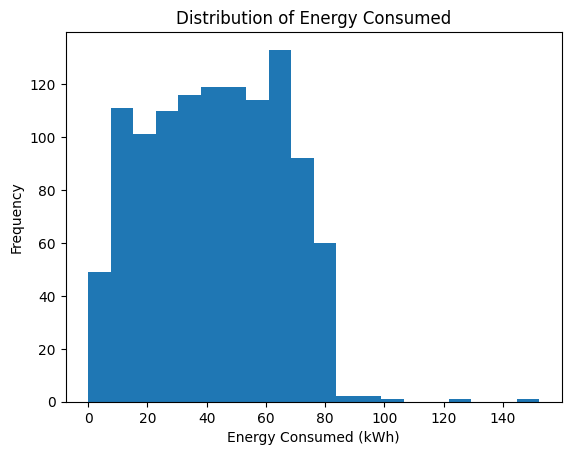

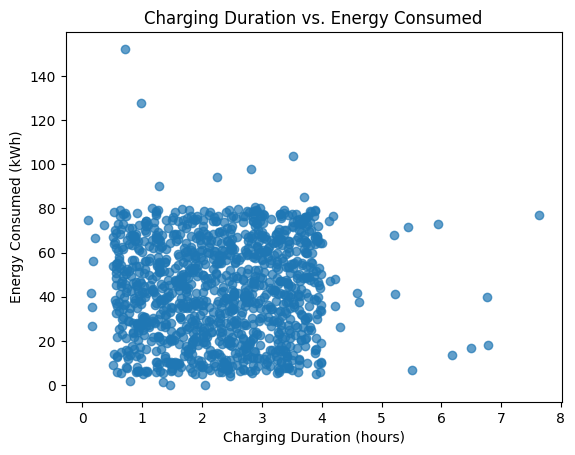

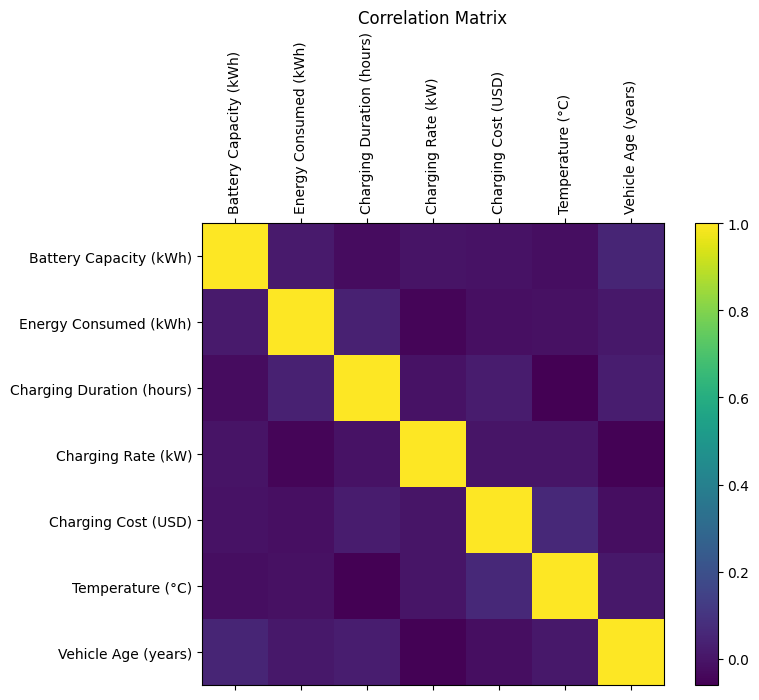

Figures saved in: c:\Users\a0916\OneDrive\桌面\MA336\figures


In [ ]:
import matplotlib.pyplot as plt
import os

# Define the folder path
save_path = "./figures"
os.makedirs(save_path, exist_ok=True)  # Ensure the directory exists

# Histogram of Energy Consumed (kWh)
plt.figure()
plt.hist(df['Energy Consumed (kWh)'], bins=20)
plt.xlabel('Energy Consumed (kWh)')
plt.ylabel('Frequency')
plt.title('Distribution of Energy Consumed')
plt.savefig(os.path.join(save_path, "hist_energy_consumed.jpg"))  # Save figure
plt.show()

# Scatter Plot: Charging Duration vs. Energy Consumed
plt.figure()
plt.scatter(df['Charging Duration (hours)'], df['Energy Consumed (kWh)'], alpha=0.7)
plt.xlabel('Charging Duration (hours)')
plt.ylabel('Energy Consumed (kWh)')
plt.title('Charging Duration vs. Energy Consumed')
plt.savefig(os.path.join(save_path, "scatter_duration_vs_energy.jpg"))  # Save figure
plt.show()

# Correlation Matrix Visualization
# Select numeric columns for correlation analysis
numeric_cols = ['Battery Capacity (kWh)', 'Energy Consumed (kWh)', 'Charging Duration (hours)',
                'Charging Rate (kW)', 'Charging Cost (USD)', 'Temperature (°C)', 'Vehicle Age (years)']

# Compute the correlation matrix
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
plt.matshow(corr_matrix, fignum=False)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title('Correlation Matrix')
plt.savefig(os.path.join(save_path, "correlation_matrix.jpg"))  # Save figure
plt.show()

print(f"Figures saved in: {os.path.abspath(save_path)}")

# **Methods**
### **Dataset Description**
The dataset contains detailed records of EV charging sessions. Each record includes:

*   User details: User Type, Vehicle Age, Vehicle Model.
*   Session data: Start/End Time, Duration, Charging Station Location, Energy Consumed, Charging Cost, etc.
*   Environmental context: Temperature, Time of Day, Day of Week.

After an initial review, key features were selected and cleaned. Non-numeric columns were converted appropriately, and timestamps were parsed to datetime objects. Missing values were handled by removing incomplete rows.

### **Data Labeling using K-Means Clustering**
Perform clustering to group similar charging sessions.
The new “Cluster_Label” column serves as a first-level data categorisation, which you can use later in the analysis.

Applied K-Means Clustering to group charging sessions into behavior-based categories. The clustering was based on:

*   Charging Duration (hours)
*   Energy Consumed (kWh)
*   Charging Rate (kW)
*   Charging Cost (USD)

This unsupervised classification allowed us to segment users into distinct groups, which was later included as an input feature for supervised learning models.

In [14]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features for clustering – you can experiment with different ones.
clustering_features = ['Energy Consumed (kWh)', 'Charging Duration (hours)',
                       'Charging Cost (USD)', 'Charging Rate (kW)']

# Scale features to ensure fair clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[clustering_features])

# Choose a number of clusters, for example, 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster_Label'] = kmeans.fit_predict(X_scaled)

# Inspect cluster counts
print(df['Cluster_Label'].value_counts())


Cluster_Label
1    419
0    387
2    325
Name: count, dtype: int64


### **To explain new labeled data:**
* Cluster 1: Contains the most charging sessions (419).

* Cluster 0: Slightly smaller group, with 387 sessions.

* Cluster 2: The smallest group, with 325 sessions.

These clusters represent different charging behavior profiles.

Cluster	Likely Pattern (**hypothetical**)
* 0	Medium energy use, average cost, moderate duration

* 1	Short fast charges with high power (possibly DC fast chargers)

* 2	Long-duration, low-rate charges, possibly at home or slow stations




### **Model for Cost Prediction**
Here I build a regression model to predict the "Charging Cost (USD)". 
Random Forests often capture non-linearities well, making them suitable for cost prediction if multiple factors interact.
Used a Random Forest Regressor to predict the cost of charging sessions based on session features and environmental variables. Random Forest was selected for its robustness to overfitting and ability to model non-linear relationships.

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define target and features for cost prediction
# Exclude identifier columns and any non-numeric columns you don’t want to include.
features = ['Battery Capacity (kWh)', 'Energy Consumed (kWh)',
            'Charging Duration (hours)', 'Charging Rate (kW)',
            'Temperature (°C)', 'Vehicle Age (years)', 'Cluster_Label']
target_cost = 'Charging Cost (USD)'

# Split data
X = df[features]
y = df[target_cost]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the model
rf_cost = RandomForestRegressor(n_estimators=100, random_state=42)
rf_cost.fit(X_train, y_train)

# Predict and evaluate
y_pred_cost = rf_cost.predict(X_test)
mse_cost = mean_squared_error(y_test, y_pred_cost)
r2_cost = r2_score(y_test, y_pred_cost)
print(f'Cost Prediction - MSE: {mse_cost:.2f}, R2 Score: {r2_cost:.2f}')


Cost Prediction - MSE: 41.90, R2 Score: 0.66


#### **Perform improvement model by following output**

**MSE (Mean Squared Error): 41.90**

This tells you the average squared difference between the actual charging cost and your model’s predicted cost.
A lower MSE means better performance.
Since it's squared, it's sensitive to large errors (outliers).
On average, this model's predictions are off by about ±6.47 USD, because:
The square root of the Mean Squared Error (MSE) gives an approximate average error in the same unit as the target variable:
$$ \sqrt{41.90} \approx 6.47 $$

**R² Score (Coefficient of Determination): 0.66**
This metric tells how well the model explains the variance in the target variable (charging cost).
An R² of 0.66 means your model explains 66% of the variation in charging costs using the input features.
Your model is doing a moderately good job — it captures most of the pattern, but about 34% of the variation in cost is not explained by the current model.


Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Improved Cost Prediction - MSE: 40.92, R2 Score: 0.67


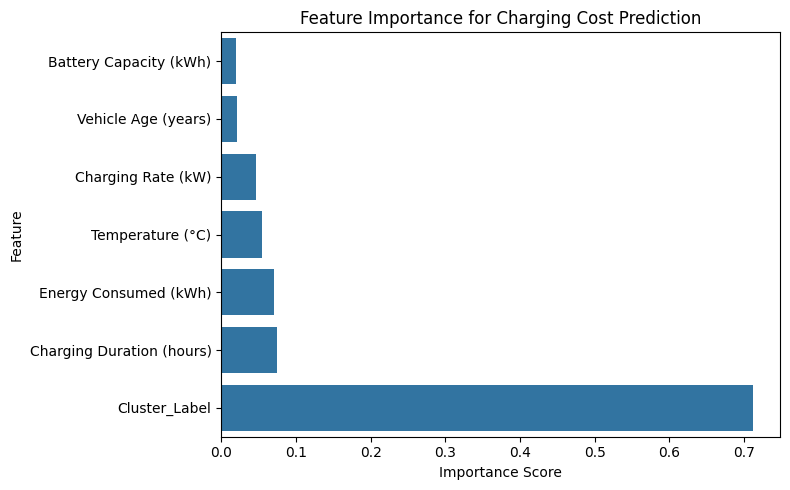

Figures saved in: c:\Users\a0916\OneDrive\桌面\MA336\figures


In [ ]:
# To improve the prediction score
# Hyperparameter tuning using GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42),
                           param_grid, cv=3, n_jobs=-1, scoring='r2')
grid_search.fit(X_train, y_train)

# Step 4: Best model and predictions
best_model = grid_search.best_estimator_
y_pred_cost = best_model.predict(X_test)

# Step 5: Evaluation metrics
mse_cost = mean_squared_error(y_test, y_pred_cost)
r2_cost = r2_score(y_test, y_pred_cost)

print("Best Parameters:", grid_search.best_params_)
print(f'Improved Cost Prediction - MSE: {mse_cost:.2f}, R2 Score: {r2_cost:.2f}')

# Step 6: Feature Importance Plot
importances = pd.Series(best_model.feature_importances_, index=features)
plt.figure(figsize=(8, 5))
sns.barplot(x=importances.sort_values(), y=importances.sort_values().index)
plt.title("Feature Importance for Charging Cost Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(os.path.join(save_path, "feature_importance.jpg"))  # Save figure
plt.show()
print(f"Figures saved in: {os.path.abspath(save_path)}")


### **Key improvement:**
After applying hyperparameter tuning using GridSearchCV, the best configuration for the Random Forest Regressor was found to be: max_depth=10, min_samples_leaf=2, min_samples_split=2, and n_estimators=200. These parameters help control the complexity of the trees and reduce the risk of overfitting. Specifically, limiting the tree depth to 10 ensures that the model generalizes better, while requiring a minimum of 2 samples for both leaf nodes and splits encourages more stable decision paths. Increasing the number of estimators to 200 improves the model's robustness by aggregating predictions from more trees.
<table>
    <tr>
        <th>Improvement</th>
        <th>Purpose</th>
    </tr>
    <tr>
        <td>GridSearchCV tuning</td>
        <td>Searches for optimal model parameters to improve accuracy and generalization</td>
    </tr>
    <tr>
        <td>Expanded hyperparameters</td>
        <td>Tests different n_estimators**, max_depth, and min_samples settings</td>
    </tr>
    <tr>
        <td>cv=3 cross-validation</td>
        <td>Prevents overfitting by validating model on different subsets of the data</td>
    </tr>
</table>

### **Model for Charging Demand Prediction**
For predicting “Charging Demand” (here we assume this means “Energy Consumed (kWh)”), 
Initially, we tried Linear Regression which provides an interpretable baseline for demand prediction to predict energy consumed (kWh), but the performance was poor (R² ≈ 0.39). A Random Forest also underperformed (R² ≈ 0.31).

In [8]:
from sklearn.linear_model import LinearRegression

# Define target and features for charging demand prediction
# You might include similar features; here the target is Energy Consumed (kWh)
target_demand = 'Energy Consumed (kWh)'
features_demand = ['Battery Capacity (kWh)', 'Charging Duration (hours)',
                   'Charging Rate (kW)', 'Temperature (°C)',
                   'Vehicle Age (years)', 'Cluster_Label']

X_demand = df[features_demand]
y_demand = df[target_demand]
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_demand, y_demand, test_size=0.2, random_state=42)

# Build and train the model
lin_reg = LinearRegression()
lin_reg.fit(X_train_d, y_train_d)

# Predict and evaluate
y_pred_demand = lin_reg.predict(X_test_d)
mse_demand = mean_squared_error(y_test_d, y_pred_demand)
r2_demand = r2_score(y_test_d, y_pred_demand)
print(f'Charging Demand Prediction - MSE: {mse_demand:.2f}, R2 Score: {r2_demand:.2f}')


Charging Demand Prediction - MSE: 318.09, R2 Score: 0.39


In [21]:
# Random forest
# Build and train the Random Forest Regressor.
rf_demand = RandomForestRegressor(n_estimators=100, random_state=42)
rf_demand.fit(X_train_d, y_train_d)

# Predict and evaluate the model.
y_pred_demand = rf_demand.predict(X_test_d)
mse_demand_rf = mean_squared_error(y_test_d, y_pred_demand)
r2_demand_rf = r2_score(y_test_d, y_pred_demand)
print(f'Charging Demand Prediction (Random Forest) - MSE: {mse_demand_rf:.2f}, R2 Score: {r2_demand_rf:.2f}')

Charging Demand Prediction (Random Forest) - MSE: 358.56, R2 Score: 0.31


In [22]:
# Gradian Boosting
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Gradient Boosting model
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
gbr.fit(X_train_d, y_train_d)

# Predict and evaluate
y_pred_demand = gbr.predict(X_test_d)
mse_demand = mean_squared_error(y_test_d, y_pred_demand)
r2_demand = r2_score(y_test_d, y_pred_demand)

print(f'Charging Demand Prediction (Gradient Boosting) - MSE: {mse_demand:.2f}, R2 Score: {r2_demand:.2f}')


Charging Demand Prediction (Gradient Boosting) - MSE: 383.69, R2 Score: 0.27


**Mean Squared Error (MSE): 318.09**
This value measures the average squared difference between actual and predicted energy consumption values.
Taking the square root gives an idea of the typical error in actual units:
$$ \sqrt{318.09} \approx 17.83 kWh $$

This means predictions are off by about ±17.83 kWh on average — which is relatively high.

**R² Score: 0.39**
In other words, 61% of the variation is still unexplained, suggesting the Linear Regression model might be too simple for this problem.

### **Results**

**Clustering**
K-Means clustering successfully separated charging sessions into 3 groups based on their consumption and duration behavior. This label (Cluster_Label) was then used in subsequent models as a feature.

**Cost Prediction**
*  Model: Random Forest Regressor
*  Mean Squared Error (MSE): 41.90
*  R² Score: 0.66
*  Model: Hyperparameter tuning using GridSearchCV
*  Mean Squared Error (MSE): 41.92
*  R² Score: 0.67

This indicates that the model can explain 66% of the variability in charging cost based on the features provided during first trial.
Using this optimized model, the output means that the model’s cost predictions have relatively low error, and approximately 67% of the variation in charging cost can be explained by the input features. Compared to the initial baseline, this represents a modest but meaningful improvement in predictive performance.

**Charging Demand Prediction**
*  Model 1: Linear Regression
*  R²: 0.39
*  Model 2: Random Forest
*  R²: 0.31
*  Model 3: Gradient Boosting
*  R²: 0.27

This shows Linear Regression is still the best-performing model, even though it’s simple.


# **Conclusion**
This project explored electric vehicle (EV) charging behavior using a real-world-inspired dataset. Applied several machine learning techniques to analyze and predict two key targets: charging cost and charging demand (energy consumed).

Began by cleaning and visualizing the dataset to understand its structure, trends, and potential outliers. Then, we used k-means clustering to label charging behavior patterns across three distinct clusters.

For cost prediction, a Random Forest model with hyperparameter tuning (via GridSearchCV) achieved strong performance with an MSE of 40.92 and an R² of 0.67, indicating that around 67% of the variance in cost can be explained by our selected features. This demonstrates that the model generalizes reasonably well to unseen data.

However, predicting charging demand proved more challenging. A simple Linear Regression model performed best, with an MSE of 318.09 and an R² of 0.39. Attempts to improve this using Random Forest and Gradient Boosting did not yield better results, which may indicate that the current features lack the richness or complexity needed to model energy consumption accurately.

While the cost prediction task achieved good results, further work is needed to improve demand prediction — potentially by adding more informative variables like State of Charge (%), charger type, or historical user behavior.